In [1]:
!pip install torchmetrics
from mpl_toolkits.axes_grid1.axes_grid import ImageGrid
import torchmetrics
import torch, matplotlib.pyplot as plt, pandas as pd, numpy as np, scipy, seaborn as sns
from torch import tensor, Tensor, optim
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.init import uniform_
from torch.serialization import add_safe_globals
from torch.nn import functional as F, Sequential, Linear, Softmax, Sigmoid, CrossEntropyLoss, MSELoss, ReLU, LeakyReLU

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 2.5 MB/s eta 0:00:00


# **Object Oriented Programming**

- **`__init__`** is called when BankAccount object is created
- `balance` is an attribute of the `BankAccount` object
- `deposit` is a method that increases balance

In [ ]:
class BankAccount:
    def __init__(self, balance):
        self.balance = balance
    def deposit(self, amount):
        self.balance += amount

account = BankAccount(100)
account.deposit(15)
print(account.balance)

115


In [ ]:
df = pd.read_csv('/content/water_potability.csv')
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,0.587349,0.577747,0.386298,0.568199,0.647347,0.292985,0.654522,0.795029,0.630115,0
1,0.643654,0.441300,0.314381,0.439304,0.514545,0.356685,0.377248,0.202914,0.520358,0
2,0.388934,0.470876,0.506122,0.524364,0.561537,0.142913,0.249922,0.401487,0.219973,0
3,0.725820,0.715942,0.506141,0.521683,0.751819,0.148683,0.467200,0.658678,0.242428,0
4,0.610517,0.532588,0.237701,0.270288,0.495155,0.494792,0.409721,0.469762,0.585049,0
...,...,...,...,...,...,...,...,...,...,...
2006,0.636224,0.580511,0.277748,0.418063,0.522486,0.342184,0.310364,0.402799,0.627156,1
2007,0.470143,0.548826,0.301347,0.538273,0.498565,0.231359,0.565061,0.175889,0.395061,1
2008,0.817826,0.087434,0.656389,0.670774,0.369089,0.431872,0.563265,0.285745,0.578674,1
2009,0.424187,0.464092,0.459656,0.541633,0.615572,0.388360,0.397780,0.449156,0.440004,1


**`super().__init__()`** ensures
`WaterDataset` behaves like torch
`Dataset`

In [ ]:
from torch.utils.data import Dataset # Not TensorDataset?

class WaterDataset(Dataset): # inherit from torch.utils.data.Dataset
    def __init__(self, csv_path):
        super().__init__()
        df = pd.read_csv(csv_path)
        self.data = df.to_numpy()

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        features = self.data[idx, :-1]
        label = self.data[idx, -1]
        return features, label

In [ ]:
from torch.utils.data import DataLoader

dataset_train = WaterDataset("water_train.csv")
dataloader_train = DataLoader(dataset_train, batch_size=2, shuffle=True)

features, labels = next(iter(dataloader_train))
print(f"Features: {features},\nLabels: {labels}")

Features: tensor([[0.5136, 0.4272, 0.4116, 0.6575, 0.5604, 0.5018, 0.4758, 0.4038, 0.2626],
        [0.6551, 0.4550, 0.3993, 0.5122, 0.6988, 0.4257, 0.5322, 0.3137, 0.5048]],
       dtype=torch.float64),
Labels: tensor([0., 0.], dtype=torch.float64)


## **Previous PyTorch Model**

In [ ]:
net = Sequential(Linear(9, 16),
                 ReLU(),
                 Linear(16, 8),
                 ReLU(),
                 Linear(8, 1),
                 Sigmoid())

net

Sequential(
  (0): Linear(in_features=9, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)

## **Class-based model definition**

In [ ]:
from torch.nn import Module
import torch.nn as nn

class Net(Module):
    def __init__(self):
        super().__init__()
        self.fc1 = Linear(9, 16)
        self.fc2 = Linear(16, 8)
        self.fc3 = Linear(8, 1)

    def forward(self, x):
        x = nn.functional.relu(self.fc1(x))
        x = nn.functional.relu(self.fc2(x))
        x = nn.functional.sigmoid(self.fc3(x))
        return x

net = Net()
net

Net(
  (fc1): Linear(in_features=9, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=1, bias=True)
)

#### ***Exercise: PyTorch Dataset***

Before model training can commence, you need to load the data and pass it to the model in the right format. In PyTorch, this is handled by **`Datasets`** and **`DataLoaders`**. Let's start with building a PyTorch Dataset for our water potability data.

In this exercise, you will define a class called `WaterDataset` to load the data from a CSV file. To do this, you will need to implement the three methods which PyTorch expects a Dataset to have:

- **`.__init__()`** to load the data,
- **`.__len__()`** to return data size,
- **`.__getitem()__`** to extract features and label for a single sample.

#### ***Instructions***

- In the **`.__init__()`** method, load the data from `csv_path` to a pandas DataFrame and assign it to `df`.
- Convert `df` to a NumPy array and assign the result to `self.data`.
- Implement the **`.__len__()`** method to return the number of data samples.
- In the **`.__getitem__()`** method, get the `label` by slicing `self.data` to extract its last column for the index `idx`, similarly to how it's done for the `features`.

In [ ]:
class WaterDataset(Dataset):
    def __init__(self, csv_path):
        super().__init__()
        # Load data to pandas DataFrame
        df = pd.read_csv(csv_path)
        # Convert data to a NumPy array and assign to self.data
        self.data = df.to_numpy().astype('float32')

    # Implement __len__ to return the number of data samples
    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        features = self.data[idx, :-1]
        # Assign last data column to label
        label = self.data[idx, -1]
        return features, label

#### ***Exercise: PyTorch DataLoader***

Good job defining the Dataset class! The `WaterDataset` you just created is now available for you to use.

The next step in preparing the training data is to set up a `DataLoader`. A PyTorch `DataLoader` can be created from a Dataset to load data, split it into batches, and perform transformations on the data if desired. Then, it yields a data sample ready for training.

In this exercise, you will build a `DataLoader` based on the `WaterDataset`. The **`DataLoader`** class you will need has already been imported for you from **`torch.utils.data`**.

#### ***Instructions***

- Create an instance of `WaterDataset` from `water_train.csv`, assigning it to `dataset_train`.

- Create `dataloader_train` based on `dataset_train`, using a batch size of two and shuffling the samples.

- Get a batch of features and labels from the DataLoader and print them.

In [ ]:
# Create an instance of the WaterDataset
dataset_train = WaterDataset("water_train.csv")

# Create a DataLoader based on dataset_train
dataloader_train = DataLoader(dataset_train, batch_size=2, shuffle=True)

# Get a batch of features and labels
features, labels = next(iter(dataloader_train))
print(features, labels)

tensor([[0.5111, 0.1024, 0.6439, 0.4898, 0.8357, 0.5460, 0.2080, 0.5867, 0.6943],
        [0.4608, 0.4653, 0.3989, 0.4108, 0.5732, 0.3324, 0.3976, 0.5546, 0.6992]]) tensor([0., 0.])


#### ***Exercise: PyTorch Model***

You will use the OOP approach to define the model architecture. Recall that this requires setting up a model class and defining two methods inside it:

- **`.__init__()`**, in which you define the layers you want to use;

- **`forward()`**, in which you define what happens to the model inputs once it receives them; this is where you pass inputs through pre-defined layers.

Let's build a model with three linear layers and ReLU activations. After the last linear layer, you need a sigmoid activation instead, which is well-suited for binary classification tasks like our water potability prediction problem. Here's the model defined using **`nn.Sequential()`**, which you may be more familiar with:

```
net = nn.Sequential(
  nn.Linear(9, 16),
  nn.ReLU(),
  nn.Linear(16, 8),
  nn.ReLU(),
  nn.Linear(8, 1),
  nn.Sigmoid(),
)
```

#### ***Instructions***

- In the **`.__init__()`** method, define the three linear layers with dimensions corresponding to the model definition provided and assign them to `self.fc1`, `self.fc2`, and `self.fc3`, respectively.
- In the `forward()` method, pass the model input `x` through all the layers, remembering to add activations on top of them, similarly how it's already done for the first layer.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # Define the three linear layers
        self.fc1 = nn.Linear(9, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 1)

    def forward(self, x):
        # Pass x through linear layers adding activations
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x)) # F.sigmoid is deprecated
        return x

net = Net()

# **Optimizers, training, and evaluation**

## **Training Loop**

In [ ]:
from torch.nn import BCELoss
import torch.optim as optim

criterion = BCELoss() # Binary Cross Entropy: BCELoss for binary classification
optimizer = optim.SGD(net.parameters(), lr=0.01) # net was constructed above

for epoch in range(1000):
    for features, labels in dataloader_train:
        optimizer.zero_grad() # Clear gradients
        outputs = net(features) # Forward pass: get model's outputs
        # .view(-1, 1) คือการ reshape labels to match the shape of outputs
        loss = criterion(outputs, labels.view(-1, 1)) # Compute loss
        loss.backward() # Compute gradients
        optimizer.step() # Optimizer's step: update params based on gradients


## **How an optimizer works**

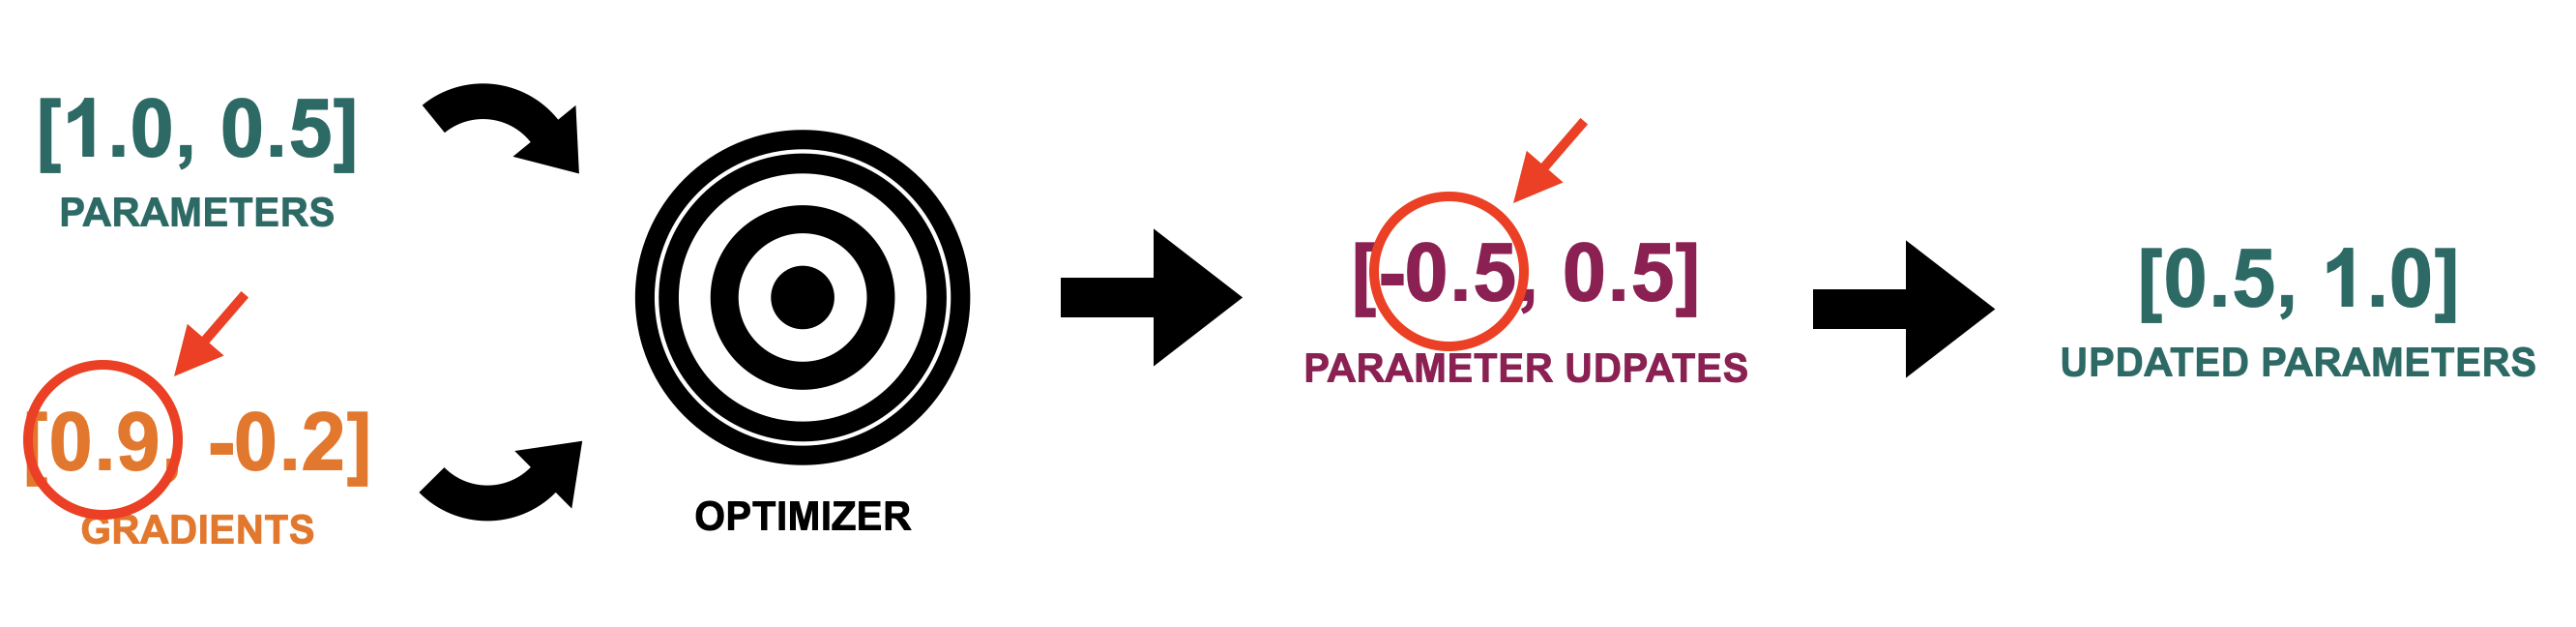

## **Stochastic Gradient Descent (SGD)**

- Rarely used in practice

In [ ]:
optimizer = optim.SGD(net.parameters(), lr=0.01)

## **Adaptive Gradient (Adagrad)**

- Good for sparse data

In [ ]:
optimizer = optim.Adagrad(net.parameters(), lr=0.01)

## **Root Mean Square Propagation (RMSprop)**

- Update for each parameter based on the size of its previous gradients

In [ ]:
optimizer = optim.RMSprop(net.parameters(), lr=0.01)

## **Adaptive Moment Estimation (Adam)**

- mostly used

In [ ]:
optimizer = optim.Adam(net.parameters(), lr=0.01)

## **Model evaluation**

In [ ]:
from torchmetrics import Accuracy

acc = Accuracy(task='binary')
with torch.no_grad():
    for i, j in dataloader_test:
        outputs = net(i)
        preds = (outputs >= 0.5).float()
        acc(preds, labels.view(-1, 1))

accuracy = acc.compute()

In [ ]:
from torchmetrics import Accuracy
from torch.utils.data import DataLoader

dataset_test = WaterDataset("water_test.csv")
dataloader_test = DataLoader(dataset_test, batch_size=2, shuffle=True)

acc = Accuracy(task='binary') # Set up accuracy metric

net.eval() # Put model in eval mode

with torch.no_grad(): # no need for gradients since no update any more
    for features, labels in dataloader_test: # iterate over test data batches
        outputs = net(features) # pass data to model to get predicted probability
        preds = (outputs >= 0.5).float() # Compute predicted labels
        acc(preds, labels.view(-1, 1)) # update accuracy metric

accuracy = acc.compute()
print(f"Accuracy: {accuracy}")

Accuracy: 0.7427055835723877


#### ***Exercise: Optimizers***

It's time to explore the different optimizers that you can use for training your model.

A custom function called `train_model(optimizer, net, num_epochs)` has been defined for you. It takes the optimizer, the model, and the number of epochs as inputs, runs the training loops, and prints the training loss at the end.

Let's use `train_model()` to run a few short trainings with different optimizers and compare the results!

#### ***Instructions***

- Define the `optimizer` as Stochastic Gradient Descent.

-  Define the optimizer as Root Mean Square Propagation (`RMSprop`), passing the model's parameters as its first argument.

- Define the optimizer as Adaptive Moments Estimation (`Adam`), setting the learning rate to `0.001`.

In [ ]:
import torch.optim as optim

def train_model(optimizer, net, num_epochs):
    criterion = nn.BCELoss()
    for epoch in range(num_epochs):
        running_loss = 0.
        for features, labels in dataloader_train:
            optimizer.zero_grad()
            outputs = net(features)
            loss = criterion(outputs, labels.view(-1, 1))
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
    train_loss = running_loss / len(dataloader_train)
    print(f"Training loss after {num_epochs} epochs: {train_loss}")

In [ ]:
net = Net()

# Define the SGD optimizer
optimizer = optim.SGD(net.parameters(), lr=0.001)

train_model(optimizer=optimizer, net=net, num_epochs=10)

Training loss after 10 epochs: 0.6735536529625759


In [ ]:
net = Net()

# Define the RMSprop optimizer
optimizer = optim.RMSprop(net.parameters(), lr=0.001)

train_model(optimizer=optimizer, net=net, num_epochs=10)

Training loss after 10 epochs: 0.670961965102732


In [ ]:
net = Net()

# Define the Adam optimizer
optimizer = optim.Adam(net.parameters(), lr=0.001)

train_model(optimizer=optimizer, net=net, num_epochs=10)

Training loss after 10 epochs: 0.672418399064231


#### ***Exercise: Model evaluation***

With the training loop sorted out, you have trained the model for 1000 epochs, and it is available to you as `net`. You have also set up a `test_dataloader` in exactly the same way as you did with `train_dataloader` before—just reading the data from the test rather than the train directory.

You can now evaluate the model on test data. To do this, you will need to write the evaluation loop to iterate over the batches of test data, get the model's predictions for each batch, and calculate the accuracy score for it. Let's do it!

#### ***Instructions***

- Set up the evaluation metric as `Accuracy` for binary classification and assign it to `acc`.
- For each batch of test data, get the model's outputs and assign them to `outputs`.
- After the loop, compute the total test accuracy and assign it to `test_accuracy`.

In [ ]:
import torch
from torchmetrics import Accuracy

# Set up binary accuracy metric
acc = Accuracy(task='binary')

net.eval()
with torch.no_grad():
    for features, labels in dataloader_test:
        # Get predicted probabilities for test data batch
        outputs = net(features)
        preds = (outputs >= 0.5).float()
        acc(preds, labels.view(-1, 1))

# Compute total test accuracy
test_accuracy = acc.compute()
print(f"Test accuracy: {test_accuracy}")

Test accuracy: 0.5994694828987122


# **Vanishing and Exploding Gradients**

## **Weights Initialization**



In [ ]:
import torch.nn.init as init

layer = nn.Linear(8, 1)
print(layer.weight)

Parameter containing:
tensor([[-0.1024, -0.2106, -0.2295,  0.1051, -0.2909,  0.0258, -0.2898,  0.1274]],
       requires_grad=True)


In [ ]:
init.kaiming_uniform_(layer.weight)

Parameter containing:
tensor([[ 0.5132,  0.2328, -0.7831,  0.3466, -0.0088, -0.4403, -0.2055,  0.0302]],
       requires_grad=True)

## **He/ Kaiming Initialization**

In [ ]:
import torch.nn as nn
import torch.nn.init as init

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(9, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 1)

        init.kaiming_uniform_(self.fc1.weight)
        init.kaiming_uniform_(self.fc2.weight)
        init.kaiming_uniform_(self.fc1.weight, nonlinearity='sigmoid')

        def forward(x):
            x = nn.functional.relu(self.fc1(x))
            x = nn.functional.relu(self.fc2(x))
            x = nn.functional.sigmoid(self.fc3(x))
            return x

## **Activation Functions**

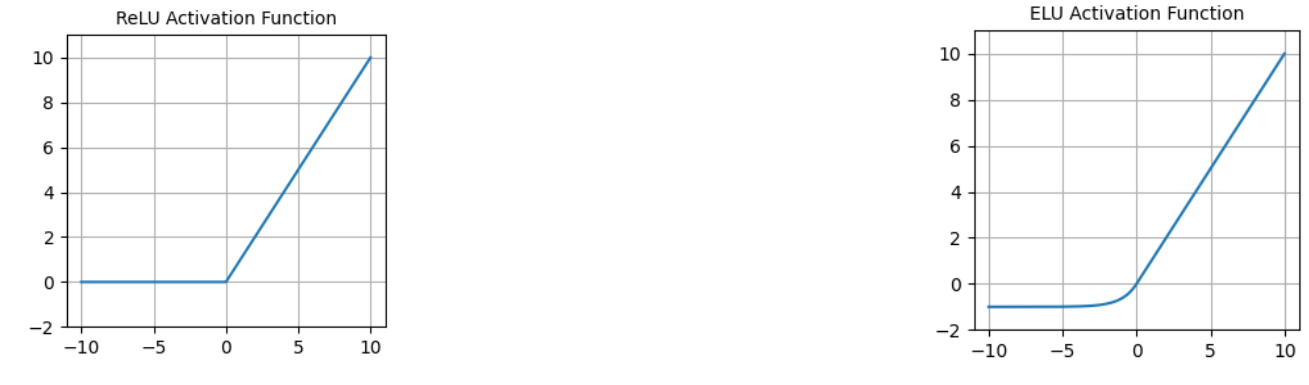

## **Batch Normalization**

In [ ]:
import torch.nn as nn
import torch.nn.init as init

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(9, 16)
        self.bn1 = nn.BatchNorm1d(16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 1)

        init.kaiming_uniform_(self.fc1.weight)
        init.kaiming_uniform_(self.fc2.weight)
        init.kaiming_uniform_(self.fc1.weight, nonlinearity='sigmoid')

        def forward(x):
            x = nn.functional.relu(self.bn1(self.fc1(x)))
            x = nn.functional.relu(self.fc2(x))
            x = nn.functional.sigmoid(self.fc3(x))
            return x

# **Loading Images to PyTorch**

* Define transformations:
  * Parse to tensor
  * Resize to 128 x 128

In [ ]:
from torchvision import transforms

train_transforms = transforms.Compose([transforms.ToTensor(),
                                       transforms.Resize((128, 128))])

## **Create dataset passing**

* First, you must upload a zipped file of the whole folders on to google colab and run `!unzip`


* Path to data
* Predefined transformations

In [ ]:
!unzip clouds.zip

In [ ]:
from torchvision.datasets import ImageFolder

dataset_train = ImageFolder("clouds/clouds_train", transform=train_transforms)

## **Displaying the images**

In [ ]:
from torch.utils.data import DataLoader

dataloader_train = DataLoader(dataset_train, batch_size=1, shuffle=True)
image, label = next(iter(dataloader_train))
print(image.shape)
# batch size of 1
# 3 colors channel
# size 128 x 128

torch.Size([1, 3, 128, 128])


To display a color image, the dimension must be rearranged so that the height and width come before number of channels

* This is not needed for grayscale

In [ ]:
image = image.squeeze().permute(1, 2, 0)
print(image.shape)

torch.Size([128, 128, 3])


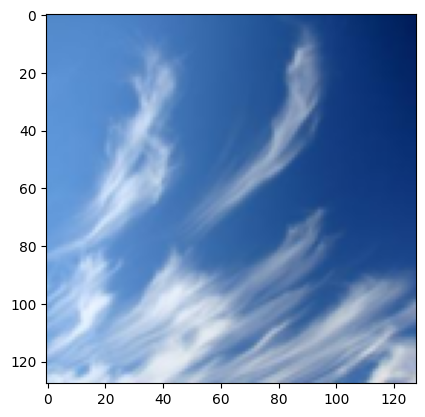

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.show()

## **Data Augmentation**

In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder

train_transforms = transforms.Compose([transforms.RandomHorizontalFlip(),
                                       transforms.RandomRotation(45),
                                       transforms.ToTensor(),
                                       transforms.Resize((128, 128))])

dataset_train = ImageFolder("clouds/clouds_train", transform=train_transforms)

# **Convolutional Neural Networks**

In [ ]:
nn.Conv2d(3, 32, kernel_size=3)
# 3 is number of input
# 32 is number of output in feature maps
# filter size = 3

## **Convolution**

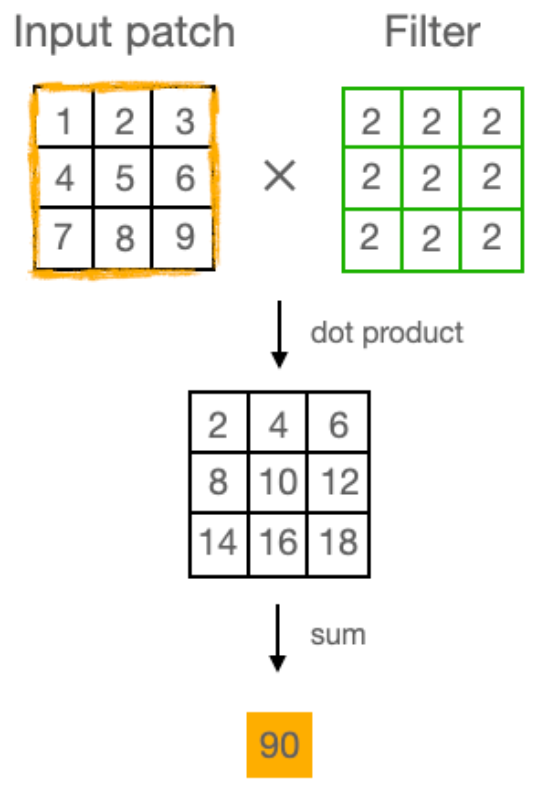

## **Zero-padding**

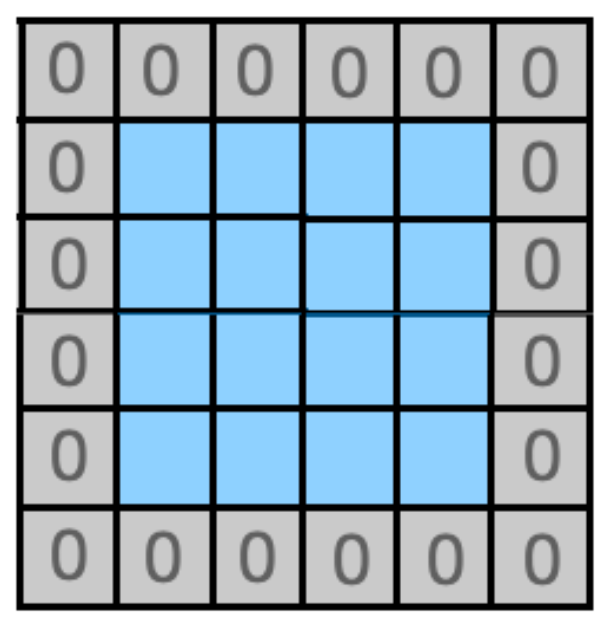

In [ ]:
nn.Conv2d(3, 32, kernel_size=3, padding=1)

## **Max Pooling**

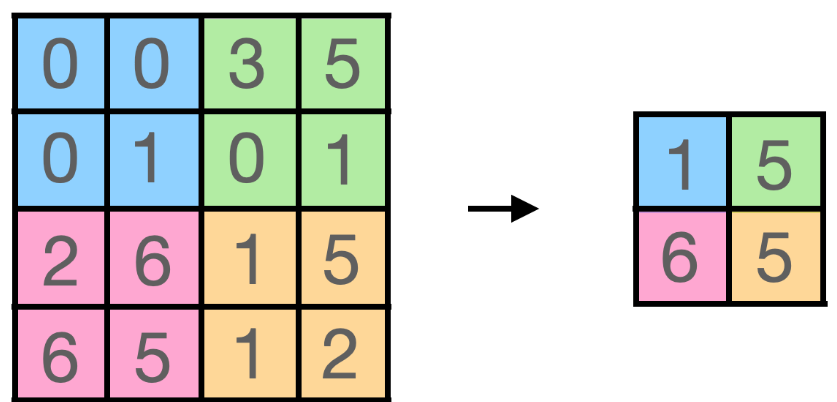

* Used after convolutional layers to reduce spatial dimensions


In [ ]:
nn.MaxPool2d(kernel_size=2)

## **Convlutional Neural Network**

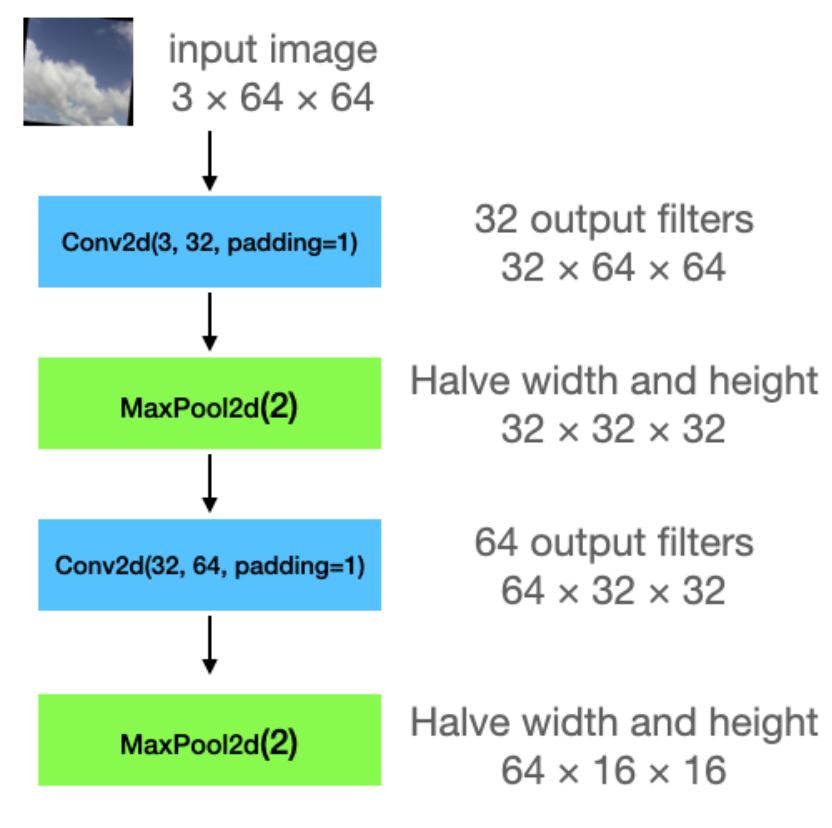

In [ ]:
from torch import nn

class Net(nn.Module):
    def __init__(self,  num_classes):
        super().__init__()
        self.feature_extractor = nn.Sequential(nn.Conv2d(3, 32, kernel_size=3, padding=1),
                                               nn.ELU(),
                                               nn.MaxPool2d(kernel_size=2),
                                               nn.Conv2d(32, 64, kernel_size=3, padding=1),
                                               nn.ELU(),
                                               nn.MaxPool2d(kernel_size=2),
                                               nn.Flatten())
        self.classifier = nn.Linear(64*16*16, num_classes)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

In [ ]:
64*16*16

16384

# **Training Image Classifier**

In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch import nn

class Net(nn.Module):
    def __init__(self,  num_classes):
        super().__init__()
        self.feature_extractor = nn.Sequential(nn.Conv2d(3, 32, kernel_size=3, padding=1),
                                               nn.ELU(),
                                               nn.MaxPool2d(kernel_size=2),
                                               nn.Conv2d(32, 64, kernel_size=3, padding=1),
                                               nn.ELU(),
                                               nn.MaxPool2d(kernel_size=2),
                                               nn.Flatten())
        self.classifier = nn.Linear(64*16*16, num_classes)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

train_transforms = transforms.Compose([transforms.RandomHorizontalFlip(),
                                       transforms.RandomRotation(45),
                                       transforms.RandomAutocontrast(),
                                       transforms.ToTensor(),
                                       transforms.Resize((64, 64))]) # Be careful here.  Size must match the classifier
dataset_train = ImageFolder("clouds/clouds_train", transform=train_transforms)
dataloader_train = DataLoader(dataset_train, batch_size=16, shuffle=True)

# 7 types of clouds
net = Net(num_classes=7)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

for epoch in range(100):
    running_loss = 0.0
    # Iterate over training batches
    for images, labels in dataloader_train:
        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader_train)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

Epoch 1, Loss: 1.8406
Epoch 2, Loss: 1.5363
Epoch 3, Loss: 1.4300
Epoch 4, Loss: 1.3680
Epoch 5, Loss: 1.2913
Epoch 6, Loss: 1.2337
Epoch 7, Loss: 1.0995
Epoch 8, Loss: 1.0792
Epoch 9, Loss: 1.0114
Epoch 10, Loss: 1.0216
Epoch 11, Loss: 0.9667
Epoch 12, Loss: 0.9108
Epoch 13, Loss: 1.0047
Epoch 14, Loss: 1.0625
Epoch 15, Loss: 1.1934
Epoch 16, Loss: 0.9929
Epoch 17, Loss: 0.8861
Epoch 18, Loss: 1.0687
Epoch 19, Loss: 0.9131
Epoch 20, Loss: 0.8928
Epoch 21, Loss: 0.9688
Epoch 22, Loss: 0.9557
Epoch 23, Loss: 0.8926
Epoch 24, Loss: 0.8629
Epoch 25, Loss: 0.9542
Epoch 26, Loss: 0.8816
Epoch 27, Loss: 0.8326
Epoch 28, Loss: 0.8302
Epoch 29, Loss: 0.8658
Epoch 30, Loss: 0.7094
Epoch 31, Loss: 0.7152
Epoch 32, Loss: 0.7156
Epoch 33, Loss: 0.7621
Epoch 34, Loss: 0.8363
Epoch 35, Loss: 0.7444
Epoch 36, Loss: 0.7666
Epoch 37, Loss: 0.7871
Epoch 38, Loss: 0.7153
Epoch 39, Loss: 0.6683
Epoch 40, Loss: 0.6528
Epoch 41, Loss: 0.5957
Epoch 42, Loss: 0.6176
Epoch 43, Loss: 0.6674
Epoch 44, Loss: 0.61

# **Evaluating Image Classifier**



## **Test data preparation**

In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch import nn

# No data augmentation
test_transforms = transforms.Compose([transforms.ToTensor(),
                                      transforms.Resize((64, 64))])
dataset_test = ImageFolder("clouds/clouds_test", transform=test_transforms)

## **Precision & Recall: Binary Classification**

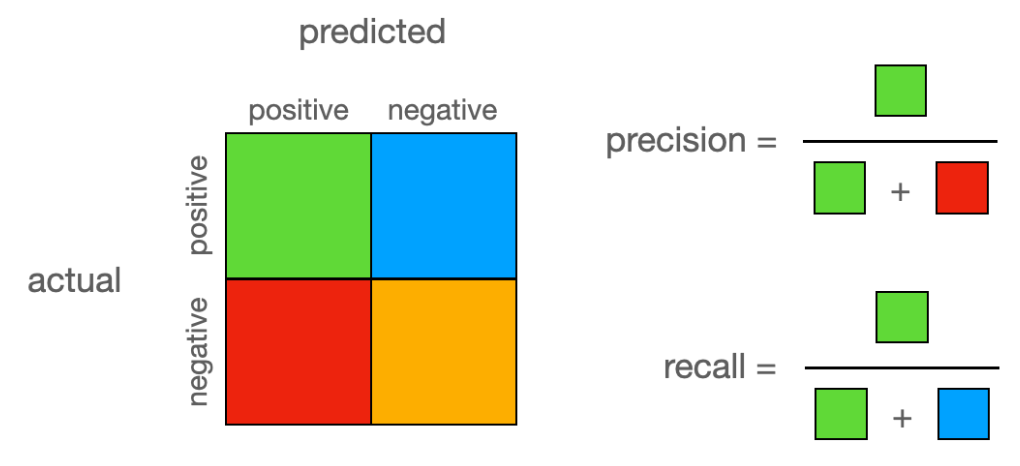


### ***Precision***

Fraction of correct positive prediction

### ***Recall***

Fraction of all positive examples correctly predicted

# **Averaging multi-class metrics**

* **Micro**: global calculation: Compute TP, FP, FN across all classes to calculate Recall, Precision
* **Macro**: Compute TP, FP, FN for each class and takes the mean across all classes to calculate Recall, Precision
* **Weighted**: Calculate Recall, Precision for each class individually and takes the weighted mean across all classes weighted by number of samples in each class

In [ ]:
from torchmetrics import Recall

recall_per_class = Recall(task='multiclass', num_classes=7, average=None)
recall_micro = Recall(task='multiclass', num_classes=7, average='micro')
recall_macro = Recall(task='multiclass', num_classes=7, average='macro')
recall_weighted = Recall(task='multiclass', num_classes=7, average='weighted')

# **Evaluation Loop**

In [ ]:
from torchmetrics import Precision, Recall

metric_precision = Precision(task='multiclass', num_classes=7, average='macro')
metric_recall = Recall(task='multiclass', num_classes=7, average='macro')

dataloader_test = DataLoader(dataset_train, batch_size=16, shuffle=True)

net.eval()
with torch.no_grad():
    for images, labels in dataloader_test:
        outputs = net(images)
        _, preds = torch.max(outputs, 1) # get the highest prob predicted class
        metric_precision(preds, labels)
        metric_recall(preds, labels)

precision = metric_precision.compute()
recall = metric_recall.compute()

In [ ]:
print(precision, recall)

tensor(0.9128) tensor(0.9052)


## **Analyzing performance per class**

In [ ]:
metric_recall = Recall(task='multiclass', num_classes=7, average=None)

net.eval()
with torch.no_grad():
    for images, labels in dataloader_test:
        outputs = net(images)
        _, preds = torch.max(outputs, 1)
        metric_recall(preds, labels)
recall = metric_recall.compute()
print(recall)

tensor([0.8333, 1.0000, 1.0000, 0.9121, 0.9248, 0.7755, 0.8525])


In [ ]:
dataset_test.class_to_idx

{'cirriform clouds': 0,
 'clear sky': 1,
 'cumulonimbus clouds': 2,
 'cumulus clouds': 3,
 'high cumuliform clouds': 4,
 'stratiform clouds': 5,
 'stratocumulus clouds': 6}

In [ ]:
{k: recall[v].item() for k, v in dataset_test.class_to_idx.items() }

{'cirriform clouds': 0.8333333134651184,
 'clear sky': 1.0,
 'cumulonimbus clouds': 1.0,
 'cumulus clouds': 0.9120879173278809,
 'high cumuliform clouds': 0.9248120188713074,
 'stratiform clouds': 0.7755101919174194,
 'stratocumulus clouds': 0.8524590134620667}

# **Preparing Sequential Data**

* Cannot use **`train_test_split`** because the sequential data order matters !

## **Example: Electricity consumption data**

* Available every 15 minutes

In [ ]:
import pandas as pd

electricity_train = pd.read_csv("/content/electricity_train.csv")
electricity_test = pd.read_csv("electricity_test.csv")
electricity_train.head()

,timestamp,consumption
0,2011-01-01 00:15:00,-0.704319
1,2011-01-01 00:30:00,-0.704319
2,2011-01-01 00:45:00,-0.678983
3,2011-01-01 01:00:00,-0.653647
4,2011-01-01 01:15:00,-0.704319


In [ ]:
import numpy as np

def create_sequences(df, length):
    inputs, targets = [], []
    for i in range(len(df) - length): # สมมติ length = 10, len(df) = 100
        input = df.iloc[i: i + length, 1] # 0 ถึง 10, 1 ถึง 11, 2 ถึง 12 ...
        target = df.iloc[i + length, 1]
        inputs.append(input)
        targets.append(target)
    return np.array(inputs), np.array(targets)

X_train, y_train = create_sequences(electricity_train, 24*4)

## **Converting sequential data into `Tensor` dataset**

In [ ]:
from torch.utils.data import TensorDataset

dataset_train = TensorDataset(torch.from_numpy(X_train).float(),
                              torch.from_numpy(y_train).float())
print(len(dataset_train))

105119


 We have 105119 training examples, each consisting of 96 inputs and 1 target value.

 # **Recurrent Neural Networks**

In [ ]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, # only 1 feature in df
                          hidden_size=32, # arbitrarily chosen
                          num_layers=2, # arbitrarily chosen
                          batch_first=True) # since the prepared data come in batch
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        # Initialization of the first hidden state with num_layers=2, hidden_state=32
        h0 = torch.zeros(2, x.size(0), 32)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        return out



# **LSTM in Pytorch**

In [ ]:
class Net(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1,
                            hidden_size=32,
                            num_layers=2,
                            batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        h0 = torch.zeros(2, x.size(0), 32)
        c0 = torch.zeros(2, x.size(0), 32) # Long term hidden state
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# **GRU in Pytorch**

In [ ]:
class Net(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.gru = nn.GRU(input_size=1,
                          hidden_size=32,
                          num_layers=2,
                          batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        h0 = torch.zeros(2, x.size(0), 32)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

RNN nowadaws are not used much due to short term memory problem.  Use LSTM or GRU.

# **Training and Evaluating RNNs**

In [ ]:
class Net(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1,
                            hidden_size=32,
                            num_layers=2,
                            batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        h0 = torch.zeros(2, x.size(0), 32)
        c0 = torch.zeros(2, x.size(0), 32) # Long term hidden state
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd, numpy as np

def create_sequences(df, length):
    inputs, targets = [], []
    for i in range(len(df) - length): # สมมติ length = 10, len(df) = 100
        input = df.iloc[i: i + length, 1] # 0 ถึง 10, 1 ถึง 11, 2 ถึง 12 ...
        target = df.iloc[i + length, 1]
        inputs.append(input)
        targets.append(target)
    return np.array(inputs), np.array(targets)

electricity_train = pd.read_csv("/content/electricity_train.csv")
X_train, y_train = create_sequences(electricity_train, 24*4)

dataset_train = TensorDataset(torch.from_numpy(X_train).float(),
                              torch.from_numpy(y_train).float())
dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)

seqs, labels = next(iter(dataloader_train))
print(seqs.shape)

torch.Size([32, 96])


We must add the dimension เพราะว่าข้อมูลการใช้ไฟฟ้านี้มีแค่ 1 feature เลยไม่มี the last dimension มาให้ในตอนแรก

In [ ]:
seqs = seqs.view(32, 96, 1)
print(seqs.shape)

torch.Size([32, 96, 1])


## **Squeezine tensors**

In [ ]:
print(labels.shape)

torch.Size([32])


In [ ]:
net = Net()
out = net(seqs)
print(out.shape)

torch.Size([32, 1])


Require the same dimension/ shape to calculate loss

In [ ]:
out = net(seqs).squeeze()
print(out.shape)

torch.Size([32])


## **RNN Training Loop**

In [ ]:
from torch import nn
import torch

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(input_size=1,
                            hidden_size=32,
                            num_layers=2,
                            batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        h0 = torch.zeros(2, x.size(0), 32)
        c0 = torch.zeros(2, x.size(0), 32)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

net = Net()
criterion = nn.MSELoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

num_epochs = 3
for epoch in range(num_epochs):
    for seqs, labels in dataloader_train:
        #seqs = seqs.view(32, 96, 1)
        seqs = seqs.unsqueeze(-1)
        outputs = net(seqs)
        loss = criterion(outputs.squeeze(), labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")


Epoch 1, Loss: 0.01851881481707096
Epoch 2, Loss: 0.0132747832685709
Epoch 3, Loss: 0.0049409265629947186


## **RNN Evaluation Loop**

* The DataCamp instructor did not provide test data preparation

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd, numpy as np

def create_sequences(df, length):
    inputs, targets = [], []
    for i in range(len(df) - length): # สมมติ length = 10, len(df) = 100
        input = df.iloc[i: i + length, 1] # 0 ถึง 10, 1 ถึง 11, 2 ถึง 12 ...
        target = df.iloc[i + length, 1]
        inputs.append(input)
        targets.append(target)
    return np.array(inputs), np.array(targets)

electricity_test = pd.read_csv("/content/electricity_test.csv")
X_test, y_test = create_sequences(electricity_test, 24*4)

dataset_test = TensorDataset(torch.from_numpy(X_train).float(),
                              torch.from_numpy(y_train).float())
dataloader_test = DataLoader(dataset_test, batch_size=32, shuffle=True)

In [ ]:
mse = torchmetrics.MeanSquaredError()

net.eval()
with torch.no_grad():
    for seqs, labels in dataloader_test:
        # seqs = seqs.view(32, 96, 1)
        seqs = seqs.unsqueeze(-1) # มีปัญหาอะไรสักอย่างเกี่ยวกับจำนวนตัวอย่างหารไม่ลงตัว
        outputs = net(seqs).squeeze()
        mse(outputs, labels)

test_mse = mse.compute()
print(f"Test MSE: {test_mse}")

Test MSE: 0.04335594177246094


In [ ]:
!unzip omniglot_train.zip

In [ ]:
!unzip omniglot_test.zip

# **Two-input Dataset**

In [ ]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class OmniglotDataset(Dataset):
    def __init__(self, transform, samples):
        self.transform = transform
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, alphabet, label = self.samples[idx]
        img = Image.open(img_path).convert('L') # load the image from PIL, L means grayscale
        img = self.transform(img)
        return img, alphabet, label

## **Two-input samples**

How can I figure this out without asking AI or fining some other resources?

In [ ]:
import os

label_counter = 0
samples = []
alphabet_to_idx = {}

root_dir = "omniglot_train"

all_alphabets = sorted(os.listdir(root_dir))

alphabet_to_idx = {alphabet: idx for idx, alphabet in enumerate(all_alphabets)}


for alphabet in os.listdir(root_dir):
    alphabet_path = os.path.join(root_dir, alphabet)
    if not os.path.isdir(alphabet_path):
        continue
    for label, character in enumerate(os.listdir(alphabet_path)):
        character_path = os.path.join(alphabet_path, character)
        if not os.path.isdir(character_path):
            continue
        for image_name in os.listdir(character_path):
            img_path = os.path.join(character_path, image_name)
            samples.append((img_path, alphabet_to_idx[alphabet], label_counter))
        label_counter += 1

## **Two-input Dataloader**

In [ ]:
dataset_train = OmniglotDataset(transform=transforms.Compose([transforms.Resize((64, 64)),
                                                              transforms.ToTensor()]),
                                samples=samples)

dataloader_train = DataLoader(dataset_train, shuffle=True, batch_size=3)

## **Tensor Concatenation**

In [ ]:
x = torch.tensor([[1, 2, 3]])
y = torch.tensor([[4, 5, 6]])

print(torch.cat((x, y), dim=0))
print(torch.cat((x, y), dim=1))

tensor([[1, 2, 3],
        [4, 5, 6]])
tensor([[1, 2, 3, 4, 5, 6]])


# **Two-input Neural Network**

In [ ]:
from torch.nn.modules import MaxPool2d
from torch import nn

class Net(nn.Module):
    def __init__(self, num_alphabets):
        super().__init__()
        # Image processing layer
        self.image_layer = nn.Sequential(nn.Conv2d(1, 16, kernel_size=3, padding=1),
                                         MaxPool2d(kernel_size=2),
                                         nn.ELU(),
                                         nn.Flatten(),
                                         nn.Linear(16*32*32, 128))
        # Alphabet processing layer
        self.alphabet_layer = nn.Sequential(nn.Linear(num_alphabets, 8),
                                            nn.ELU())

        self.classifier = nn.Sequential(nn.Linear(128 + 8, 964))

    def forward(self, x_image, x_alphabet):
        x_image = self.image_layer(x_image)
        x_alphabet = self.alphabet_layer(x_alphabet)
        x = torch.cat((x_image, x_alphabet), dim=1)
        return self.classifier(x)


## **Two-input NN Training Loop**

In [ ]:
import torch.nn.functional as F

num_alphabets = len(alphabet_to_idx)

net = Net(num_alphabets)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01)

for epoch in range(10):
    for img, alpha, labels in dataloader_train:
        num_alphabets = len(alphabet_to_idx)
        alpha = F.one_hot(alpha, num_classes=num_alphabets).float()
        optimizer.zero_grad()
        outputs = net(img, alpha)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 4.691732883453369
Epoch 2, Loss: 3.625328779220581
Epoch 3, Loss: 2.941326141357422
Epoch 4, Loss: 2.1626498699188232
Epoch 5, Loss: 1.5564384460449219
Epoch 6, Loss: 1.0296121835708618
Epoch 7, Loss: 1.8454452753067017
Epoch 8, Loss: 0.03628675267100334
Epoch 9, Loss: 0.18934766948223114
Epoch 10, Loss: 0.22362013161182404


# **Multi-output models**

In [22]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import os

class OmniglotDataset(Dataset):
    def __init__(self, transform, samples):
        self.transform = transform
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, alphabet, label = self.samples[idx]
        img = Image.open(img_path).convert('L') # load the image from PIL, L means grayscale
        img = self.transform(img)
        return img, alphabet, label

label_counter = 0
samples = []

alphabet_to_idx = {}

root_dir = "omniglot_train"

all_alphabets = sorted(os.listdir(root_dir))

alphabet_to_idx = {alphabet: idx for idx, alphabet in enumerate(all_alphabets)}


for alphabet in os.listdir(root_dir):
    alphabet_path = os.path.join(root_dir, alphabet)
    if not os.path.isdir(alphabet_path):
        continue
    for label, character in enumerate(os.listdir(alphabet_path)):
        character_path = os.path.join(alphabet_path, character)
        if not os.path.isdir(character_path):
            continue
        for image_name in os.listdir(character_path):
            img_path = os.path.join(character_path, image_name)
            samples.append((img_path, alphabet_to_idx[alphabet], label_counter))
        label_counter += 1

dataset_train = OmniglotDataset(transform=transforms.Compose([transforms.Resize((64, 64)),
                                                              transforms.ToTensor()]),
                                samples=samples)

dataloader_train = DataLoader(dataset_train, shuffle=True, batch_size=3)

## **For test data**

In [27]:
# =========================
# CREATE TEST SAMPLES
# =========================

samples_test = []

root_dir = "/content/omniglot_test/omniglot_test"

for alphabet in os.listdir(root_dir):

    alphabet_path = os.path.join(root_dir, alphabet)

    if not os.path.isdir(alphabet_path):
        continue

    for label, character in enumerate(os.listdir(alphabet_path)):

        character_path = os.path.join(alphabet_path, character)

        if not os.path.isdir(character_path):
            continue

        for image_name in os.listdir(character_path):

            img_path = os.path.join(character_path, image_name)

            samples_test.append(
                (
                    img_path,
                    alphabet_to_idx[alphabet],
                    label_counter
                )
            )

        label_counter += 1


# =========================
# CREATE TEST DATASET
# =========================

dataset_test = OmniglotDataset(
    transform=transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ]),
    samples=samples_test
)


# =========================
# CREATE TEST DATALOADER
# =========================

dataloader_test = DataLoader(
    dataset_test,
    shuffle=False,
    batch_size=3
)

## **Two-output Neural Network**

In [28]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.image_layer = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2),
            nn.ELU(),
            nn.Flatten(),
            nn.Linear(16*32*32, 128)
        )
        # Define the two classifier layers
        self.classifier_alpha = nn.Linear(128, num_alphabets)
        self.classifier_char = nn.Linear(128, 964)

    def forward(self, x):
        x_image = self.image_layer(x)
        # Pass x_image through the classifiers and return both results
        output_alpha = self.classifier_alpha(x_image)
        output_char = self.classifier_char(x_image)
        return output_alpha, output_char

## **Two-output training loop**

In [20]:
import torch.nn.functional as F

num_alphabets = len(alphabet_to_idx)

net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01)

for epoch in range(10):
    for images, labels_alpha, labels_char in dataloader_train:
        optimizer.zero_grad()
        outputs_alpha, outputs_char = net(images)
        loss_alpha = criterion(outputs_alpha, labels_alpha)
        loss_char = criterion(outputs_char, labels_char)
        loss = loss_alpha + loss_char
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 5.219257831573486
Epoch 2, Loss: 6.523401737213135
Epoch 3, Loss: 3.775555372238159
Epoch 4, Loss: 2.1110153198242188
Epoch 5, Loss: 4.559409141540527
Epoch 6, Loss: 2.5650126934051514
Epoch 7, Loss: 2.969160795211792
Epoch 8, Loss: 2.7414937019348145
Epoch 9, Loss: 0.7325798273086548
Epoch 10, Loss: 1.3572672605514526


# **Evaluation of multi-output models and loss weighting**

In [29]:
from torchmetrics import Accuracy

acc_alpha = Accuracy(task='multiclass', num_classes=31)
acc_char = Accuracy(task='multiclass', num_classes=964)

net.eval()
with torch.no_grad():
    for images, labels_alpha, labels_char in dataloader_test:
        out_alpha, out_char = net(images)
        _, pred_alpha = torch.max(out_alpha, 1)
        _, pred_char = torch.max(out_char, 1)
        acc_alpha(pred_alpha, labels_alpha)
        acc_char(pred_char, labels_char)

print(f"Alphabet: {acc_alpha.compute()}")
print(f"Character: {acc_char.compute()}")

Alphabet: 0.588772714138031
Character: 0.0
